# 先行研究2：事前分布のパラメータ初期値
## 概要
モデルにおける未知パラメータ$\lambda_0,\alpha,\theta,\gamma,\vec{y}$のベイズ推定をすることが最終的な目標。

ベイズ推定前にパラメータの事前分布における初期値を観測データのみから推定する。

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = (
    REPO_ROOT / "Merton_Poisson_Lognormal_Model_Study_and_Negative_Binomial_Extension"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4


In [2]:
# make dataframe
from src.data_loader import load_csv_with_datetime_index
from src.preprocessing import normalize_default_counts

df = load_csv_with_datetime_index(
    (RAW_DATA_DIR / "default_counts/M.csv"),
    date_col="Year",
    date_format="%Y",
)

df = normalize_default_counts(df, scale=3000)
df.head()

=== CSV loaded ===
shape: (99, 7)
columns: ['Year', 'SG', 'D_SG', 'IG', 'D_IG', 'ALL', 'D_ALL']
=== DatetimeIndex set ===
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['1920-01-01', '1921-01-01', '1922-01-01', '1923-01-01',
               '1924-01-01'],
              dtype='datetime64[ns]', name='Year', freq=None)
[normalize_default_counts] created 'SG_norm' from 'D_SG' / 'SG' * 3000
[normalize_default_counts] created 'IG_norm' from 'D_IG' / 'IG' * 3000
[normalize_default_counts] created 'ALL_norm' from 'D_ALL' / 'ALL' * 3000


,SG,D_SG,IG,D_IG,ALL,D_ALL,SG_norm,IG_norm,ALL_norm
Year,,,,,,,,,
1920-01-01,831,25,1843,8,2674,33,90.252708,13.022246,37.023186
1921-01-01,1163,25,1833,7,2996,32,64.488392,11.456628,32.042724
1922-01-01,1305,23,1972,10,3277,33,52.873563,15.212982,30.210558
1923-01-01,1290,22,2068,5,3358,27,51.162791,7.253385,24.121501
1924-01-01,1297,37,2175,3,3472,40,85.582113,4.137931,34.562212


## 初期値の作り方
### 統計量の理論値
#### 強度$\lambda_t$
$$
\mathbb{E}[\lambda_t] = \exp{(\log{\lambda_0} + \frac{\alpha^2}{2})} = \bar{\lambda} \ , \ Var(\lambda_t) = \bar{\lambda}^2 (\exp{\alpha^2}-1) = \bar{V}
$$
#### 無条件のデフォルト$X_t$
条件付きのデフォルト$X_t|y_t$と期待値の繰り返し公式を利用して
$$
\mathbb{E}[X_t] = \mathbb{E}[\mathbb{E}[X_t|y_t]] = \mathbb{E}[\lambda_t]
$$
分散も同様に
$$
Var(X_t) = \mathbb{E}[Var[X_t|y_t]] + Var[\mathbb{E}[X_t|y_t]] = \mathbb{E}[\lambda_t] + Var[\lambda_t]
$$
分散比の理論値は
$$
\frac{Var(X_t)}{\mathbb{E}[X_t]} = 1 + \frac{\bar{V}}{\bar{\lambda}} = 1 + \bar{\lambda} (\exp{\alpha^2}-1)
$$

- 個別企業がマクロの影響を受けない$\alpha = 0$ならデフォルト数は条件付きではないただのポアソン分布
- $\alpha$が大きいほど、$\lambda_t$の揺れが大きくなり、過分散が強くなる

--- 
### $\lambda_0,\alpha$
```python
estimate_poisson_mle
```
- モーメント法により$\lambda_0$を決定、$\alpha$は適当に決定
- 観測データ$k^*$と上記パラメータにより、暫定的に$y_t$を決定
- MLEを用いて初期値$\lambda_0,\alpha$を決定
- 分散は対数パラメータに対する数値ヘッセ行列の逆行列からデルタ法により換算

### $y_t$
```python
restore_latent_y
```
以下で復元
$$
y_t = \frac{\log k_t - \log {\lambda_0}}{\alpha}
$$
### $\theta , \gamma$
```python
fit_acf_exponential
fit_acf_power_law

```
- 復元した$y_t$から自己相関関数を計算
- 理論値とMLE
- 分散は非線形最小二乗推定の共分散行列

MLEは以下のLOSSを最小とするパラメータを選ぶ
$$
\text{LOSS} = \sum_{lag} (\hat{\rho}(lag) - d(lag;\theta \ \text{or}\  \gamma))^2
$$


In [3]:
from src.init_params import build_init_params, init_params_to_series

x = df["ALL_norm"].to_numpy(dtype=float)

init_params = build_init_params(x, max_lag=20)

df_init_one = init_params_to_series(init_params, name="ALL")
display(df_init_one)

group                 ALL
lambda0_init    15.371267
alpha_init       1.608366
theta_init       0.871265
gamma_init       0.553767
lambda0_se       0.478434
alpha_se         0.031045
theta_se         0.008452
gamma_se         0.041713
lambda0_var      0.228899
alpha_var        0.000964
theta_var        0.000071
gamma_var         0.00174
dtype: object

In [4]:
print(df_init_one["lambda0_init"])
print(df_init_one["alpha_init"])
print(df_init_one["theta_init"])
print(df_init_one["gamma_init"])
print("=============")
print(df_init_one["lambda0_se"])
print(df_init_one["alpha_se"])
print(df_init_one["theta_se"])
print(df_init_one["gamma_se"])

15.371267399638784
1.6083656201283254
0.8712653894606734
0.5537673935814657
0.4784335726034531
0.03104536132929653
0.00845159091048003
0.04171285345164122


In [ ]:
from src.data_loader import save_init_params

save_init_params(init_params)

[INFO] saved to C:\Users\h20s1\workspace\paper_study\Merton_Poisson_Lognormal_Model_Study_and_Negative_Binomial_Extension\data\init_para


## Fig5の再現
### 自己相関
$$
\rho(h) = \text{Corr}(y_t , y_{t + h}) = d_h
$$

### 標本自己相関

時系列 $ \{y_t\}_{t=1}^T $ に対して：

#### 平均
$$
\bar{y} = \frac{1}{T} \sum_{t=1}^{T} y_t
$$

#### 分散（ラグ0の共分散）
$$
\hat{\gamma}(0) = \frac{1}{T} \sum_{t=1}^{T} (y_t - \bar{y})^2
$$

#### ラグ $h$ の自己共分散
$$
\hat{\gamma}(h) = \frac{1}{T} \sum_{t=1}^{T-h} (y_t - \bar{y})(y_{t+h} - \bar{y})
$$

#### 標本自己相関（ACF）
$$
\hat{\rho}(h) = \frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}
$$

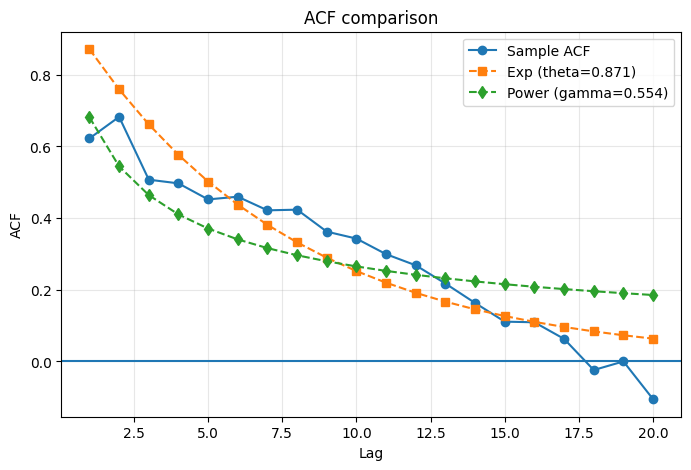

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 取り出し
lags = init_params.acf_lags
acf_values = init_params.acf_values
theta = init_params.theta_init
gamma = init_params.gamma_init

# モデルACF
rho_exp = theta**lags
rho_pow = (1.0 + lags) ** (-gamma)

# プロット
plt.figure(figsize=(8, 5))

plt.plot(lags, acf_values, "o-", label="Sample ACF")
plt.plot(lags, rho_exp, "s--", label=f"Exp (theta={theta:.3f})")
plt.plot(lags, rho_pow, "d--", label=f"Power (gamma={gamma:.3f})")

plt.axhline(0.0)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("ACF comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()